# CyberSafe USeP: Data Analysis for a Strategic Cybersecurity Literacy Framework

**Objective:** To re-analyze the CyberSafe USeP dataset to build an evidence-based, strategic cybersecurity literacy training framework.

**Our Approach:**
1.  **Setup and Cleaning:** Load and meticulously clean the three data sources (`survey`, `interview minutes`, `NVivo results`) to ensure our analysis is accurate.
2.  **Content Analysis:** Quantify the language used by the USeP community. We will count the frequency of key cybersecurity terms to identify what is well-understood versus what is ignored. This provides the "what."
3.  **Thematic Analysis:** Go beyond counting words to understand the underlying patterns, feelings, and gaps. We will code the qualitative data to uncover recurring themes. This provides the "why."
4.  **Comparative Analysis:** Dig deeper by comparing different stakeholder groups (e.g., Students vs. Staff, Technical vs. Non-technical offices) to justify the need for a differentiated framework.
5.  **Synthesis & Conclusion:** Bring all findings together to provide direct, data-driven recommendations for the components of our proposed training framework.

This notebook documents every step of that process.

In [7]:
# --- 1.1 Import Libraries ---
# These are the tools we need for our analysis.

# For data manipulation (like working with Excel files)
import pandas as pd
import re
from collections import defaultdict
import warnings

# For reading .docx files (the interview minutes)
from docx import Document

# For creating charts and graphs
import matplotlib.pyplot as plt
import seaborn as sns

# Set notebook-wide settings
warnings.filterwarnings('ignore') # Hides unnecessary warnings
pd.set_option('display.max_rows', 100) # Lets us see more rows of data at once

print("--- Step 1.1: Libraries Imported Successfully ---")

# --- 1.2 Load Data Files ---
# We load our three primary data sources into memory.

try:
    # Main survey data with 600 responses
    df_survey = pd.read_excel('data/cybersafe_data.xlsx', header=0)
    print(f"✅ 'cybersafe_data.xlsx' loaded. Shape: {df_survey.shape}")

    # Interview minutes from the focus group discussion (NOTE: filename updated here!)
    doc = Document('data/Minutes(1).docx')
    interview_text = '\n'.join([p.text for p in doc.paragraphs if p.text.strip()])
    print(f"✅ 'Minutes(1).docx' loaded.")

    # Seniors' NVivo results, used as a reference
    df_nvivo = pd.read_excel('data/results3.xlsx', header=0)
    print(f"✅ 'results3.xlsx' loaded. Shape: {df_nvivo.shape}")

except FileNotFoundError as e:
    print(f"❌ ERROR: Could not find a file. Please ensure all .xlsx and .docx files are in the same folder as this notebook.")
    print(f"   Missing file: {e.filename}")
except Exception as e:
    print(f"❌ ERROR: An unexpected error occurred: {e}")


--- Step 1.1: Libraries Imported Successfully ---
✅ 'cybersafe_data.xlsx' loaded. Shape: (600, 53)
✅ 'Minutes(1).docx' loaded.
✅ 'results3.xlsx' loaded. Shape: (16, 4)


## Part 2: Data Cleaning & Preparation

Raw data is never perfect. It contains empty rows, duplicates, and inconsistent formatting. Cleaning is a critical first step to ensure our analysis is built on a reliable foundation. Here, we will clean the main survey dataset.

In [9]:
# We will perform several cleaning steps on the main survey DataFrame (df_survey).

print("--- Starting Survey Data Cleaning ---")
original_rows = len(df_survey)

# Make a copy to preserve the original data
df_clean = df_survey.copy()

# Step 1: Drop fully empty rows where all values are missing.
df_clean.dropna(how='all', inplace=True)
print(f"Step 1: Removed {original_rows - len(df_clean)} fully empty rows.")

# Step 2: Drop exact duplicate rows.
rows_before_dedupe = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f"Step 2: Removed {rows_before_dedupe - len(df_clean)} duplicate rows.")

# Step 3: Standardize the 'Role' column for consistency.
# The 'Role' column is the 3rd column in your dataset (index 2)
role_col = df_clean.columns[2]

# We convert it to a string, remove extra spaces, and use Title Case (e.g., "student" -> "Student").
df_clean[role_col] = df_clean[role_col].astype(str).str.strip().str.title()
# Replace common non-answers with a standard 'Unknown' category.
df_clean[role_col].replace({'Nan': 'Unknown', '': 'Unknown', 'None': 'Unknown'}, inplace=True)

# Step 4: Identify and replace placeholder text in open-ended questions.
# Answers like "N/A", "None", or "wala" don't provide information, so we'll treat them as empty.
# We will grab the columns by their exact position to avoid KeyErrors
open_ended_cols = [
    df_clean.columns[6],   # Q7: What do you understand about data privacy...
    df_clean.columns[32],  # Q33: Main worries about data privacy...
    df_clean.columns[33],  # Q34: What worries you most about cybersecurity...
    df_clean.columns[49],  # Q50: Additional tools or support...
    df_clean.columns[52]   # Q53: Additional comments...
]

# This pattern looks for variations of "N/A", "none", "wala", etc. at the start and end of a string.
placeholder_pattern = re.compile(r'^\s*(n/?a\.?|none|nothing|wala|\-|\.)\s*$', re.IGNORECASE)

cleaned_cells = 0
for col in open_ended_cols:
    # Create a 'mask' to find which cells match the pattern
    mask = df_clean[col].astype(str).str.match(placeholder_pattern)
    # Count how many we found
    cleaned_cells += mask.sum()
    # Replace them with an actual empty value (NaN)
    df_clean.loc[mask, col] = pd.NA

print(f"Step 4: Converted {cleaned_cells} placeholder answers (like 'N/A') to empty cells.")
print(f"\n--- Cleaning Complete ---")
print(f"Original survey had {original_rows} rows. Cleaned survey has {len(df_clean)} rows.")

# For all following steps, we will use our newly cleaned data.
df_survey = df_clean


--- Starting Survey Data Cleaning ---
Step 1: Removed 0 fully empty rows.
Step 2: Removed 0 duplicate rows.
Step 4: Converted 147 placeholder answers (like 'N/A') to empty cells.

--- Cleaning Complete ---
Original survey had 600 rows. Cleaned survey has 600 rows.


## Part 3: Content Analysis - What Language is Being Used?

Content analysis helps us understand *what* topics are top-of-mind by counting word frequencies. We will group key terms into tiers:

*   **Tier 1 (Basic Threats):** Common threats people know (e.g., phishing, virus).
*   **Tier 2 (Protective Practices):** Actions people should take (e.g., 2FA, backup).
*   **Tier 3 (Advanced/Institutional Concepts):** Technical and policy terms (e.g., encryption, incident response).
*   **Tier 4 (Emotional Language):** Words describing feelings (e.g., scared, worried).
*   **Tier 5 (Institutional Asks):** Things people want from the university (e.g., training, policy).

This will give us a clear, quantitative picture of the "knowing-doing gap."

In [11]:
# This function is a helper to count a specific word in a large block of text.
def count_term(term, text):
    # \b ensures we match whole words only (e.g., 'hack' doesn't match 'hacking')
    pattern = r'\b' + re.escape(term.lower()) + r'\b'
    return len(re.findall(pattern, text.lower()))

# Define our term tiers
TIERS = {
    'Tier 1: Basic Threats': ['email', 'phishing', 'hacking', 'virus', 'malware', 'scam'],
    'Tier 2: Protective Practices': ['password', '2fa', 'two-factor', 'antivirus', 'update', 'backup'],
    'Tier 3: Advanced Concepts': ['encryption', 'access control', 'incident response', 'vulnerability', 'firewall', 'authentication'],
    'Tier 4: Emotional Language': ['scared', 'fear', 'worried', 'overwhelmed', 'unsafe', 'helpless'],
    'Tier 5: Institutional Asks': ['training', 'seminar', 'policy', 'guidelines', 'helpdesk', 'support'],
}

# --- Combine all text from all sources into one large "corpus" ---
# 1. Get all open-ended survey responses
survey_strings = []
for col in open_ended_cols:
    # Convert each column to a list of strings and add it to our main list
    survey_strings.extend(df_survey[col].dropna().astype(str).tolist())
survey_text = ' '.join(survey_strings)

# 2. Add the interview text
all_text = survey_text + ' ' + interview_text

# --- Count every term in our tiers ---
freq_data = []
for tier, terms in TIERS.items():
    for term in terms:
        freq_data.append({
            'Tier': tier,
            'Term': term,
            'Frequency': count_term(term, all_text)
        })

df_wordfreq = pd.DataFrame(freq_data)

print("--- Top 15 Most Frequent Key Terms ---")
print(df_wordfreq.sort_values('Frequency', ascending=False).head(15).to_string(index=False))

print("\n--- Total Mentions per Tier ---")
tier_totals = df_wordfreq.groupby('Tier')['Frequency'].sum().sort_values(ascending=False)
print(tier_totals.to_string())


--- Top 15 Most Frequent Key Terms ---
                        Tier           Term  Frequency
  Tier 5: Institutional Asks       training         66
       Tier 1: Basic Threats        hacking         56
   Tier 3: Advanced Concepts authentication         54
       Tier 1: Basic Threats          email         48
       Tier 1: Basic Threats       phishing         47
  Tier 5: Institutional Asks        support         46
Tier 2: Protective Practices       password         42
Tier 2: Protective Practices      antivirus         37
       Tier 1: Basic Threats        malware         31
Tier 2: Protective Practices     two-factor         24
  Tier 4: Emotional Language        worried         23
  Tier 5: Institutional Asks         policy         23
   Tier 3: Advanced Concepts     encryption         20
  Tier 5: Institutional Asks     guidelines         18
  Tier 5: Institutional Asks        seminar         17

--- Total Mentions per Tier ---
Tier
Tier 1: Basic Threats           198
Tier 5:

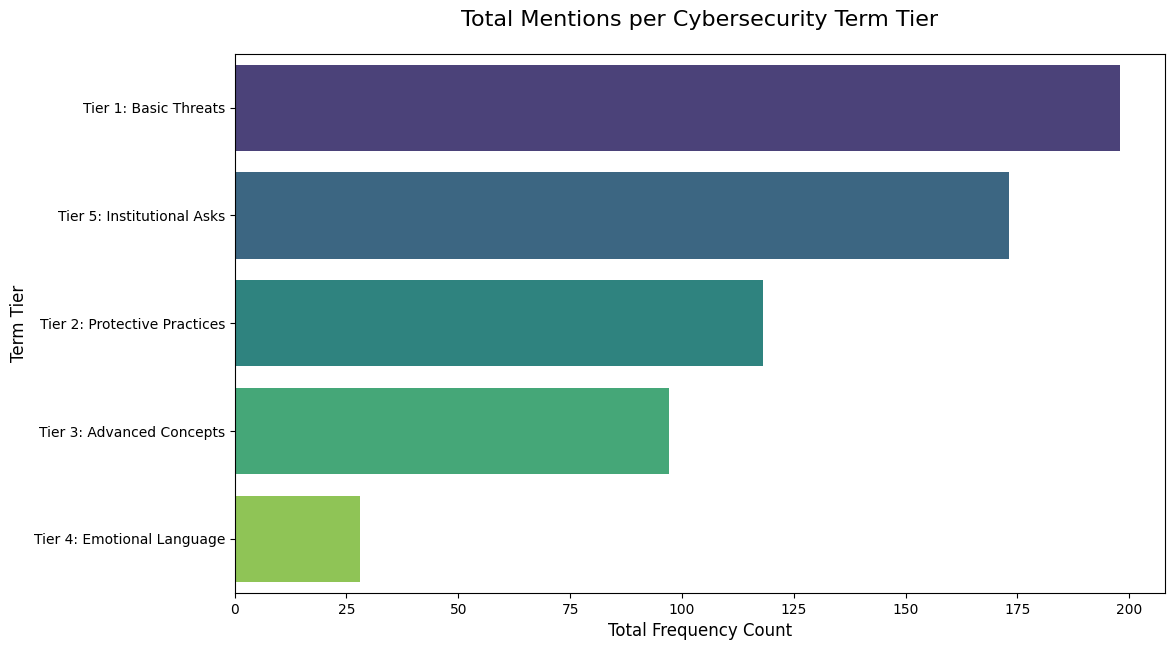


**Interpretation:**
This chart provides powerful evidence for our argument.
- **High Frequency in Tier 1 & 5:** People are very aware of basic threats ('phishing', 'scam') and are actively asking for institutional help ('training', 'policy').
- **Low Frequency in Tier 2 & 3:** Critically, they are NOT talking about the specific actions ('2FA', 'backup') or the deeper concepts ('encryption', 'incident response') that constitute strong cybersecurity practice.
- **This is the "knowing-doing gap" visualized.** They know the problem exists but lack the language and knowledge for the solutions.



In [12]:
# A chart is much easier to understand than a table.

# --- Chart 1: Bar plot of total mentions per tier ---
plt.figure(figsize=(12, 7))
sns.barplot(x=tier_totals.values, y=tier_totals.index, palette='viridis')
plt.title('Total Mentions per Cybersecurity Term Tier', fontsize=16, pad=20)
plt.xlabel('Total Frequency Count', fontsize=12)
plt.ylabel('Term Tier', fontsize=12)
plt.show()

# --- Interpretation ---
print("""
**Interpretation:**
This chart provides powerful evidence for our argument.
- **High Frequency in Tier 1 & 5:** People are very aware of basic threats ('phishing', 'scam') and are actively asking for institutional help ('training', 'policy').
- **Low Frequency in Tier 2 & 3:** Critically, they are NOT talking about the specific actions ('2FA', 'backup') or the deeper concepts ('encryption', 'incident response') that constitute strong cybersecurity practice.
- **This is the "knowing-doing gap" visualized.** They know the problem exists but lack the language and knowledge for the solutions.
""")

## Part 4: Thematic Analysis - What are the Underlying Patterns?

Now we move from *what* people are saying to *why*. Thematic analysis helps us find recurring patterns of meaning in the qualitative data.

**Our Process:**
1.  **Define a "Coding Book":** We'll create a set of rules that define codes (e.g., 'fear of being hacked') and the keywords that trigger them.
2.  **Auto-Code the Data:** Apply these rules to every open-ended survey response and every paragraph of the interview transcript.
3.  **Aggregate and Map to Themes:** Group the codes into larger, meaningful themes that answer our research questions.
4.  **Extract Supporting Quotes:** Pull direct quotes from the data to bring our themes to life.

In [15]:
# This is our "Coding Book". Each code is defined by a list of keywords.
# This approach makes our analysis systematic and repeatable.

CODING_RULES = [
    ('Fear of Hacking/Leaks', ['hack', 'hacked', 'leak', 'exposed', 'data breach', 'unauthorized']),
    ('Awareness of Phishing/Scams', ['phishing', 'scam', 'fake email', 'suspicious link', 'spam']),
    ('Emotional Distress', ['scared', 'fear', 'worry', 'anxious', 'helpless', 'overwhelm']),
    ('Passive Trust in USeP', ['trust the university', 'confident in usep', 'rely on usep', 'feel safe']),
    ('Request for Training', ['training', 'seminar', 'workshop', 'orientation', 'educate']),
    ('Request for Policy/Support', ['policy', 'guidelines', 'rules', 'helpdesk', 'support', 'it support']),
    ('Institutional Inadequacy', ['not enough', 'kulang', 'inadequate', 'lacking', 'poor', 'no']),
    ('Uncertainty/Lack of Knowledge', ['not sure', "don't know", 'unsure', 'unaware', 'no idea']),
]

# This function takes a piece of text and returns a list of all matching codes.
def apply_codes(text):
    text_lower = text.lower()
    matched_codes = [code for code, keywords in CODING_RULES if any(kw in text_lower for kw in keywords)]
    return matched_codes if matched_codes else ['Uncategorized']

# --- Apply coding to all open-ended survey responses ---
coded_responses = []

# We dynamically grab the column for "Role" just in case the exact text is mismatched
role_col = df_survey.columns[2]

for index, row in df_survey.iterrows():
    for col in open_ended_cols:
        response = str(row[col])
        if pd.notna(row[col]) and len(response.strip()) > 5:
            codes = apply_codes(response)
            coded_responses.append({
                'Source': 'Survey',
                'Role': row[role_col], # <--- FIXED HERE
                'Response': response,
                'Codes': codes
            })

# --- Apply coding to the interview transcript ---
for paragraph in interview_text.split('\n'):
    if len(paragraph.strip()) > 20: # Only analyze substantial paragraphs
        codes = apply_codes(paragraph)
        coded_responses.append({
            'Source': 'Interview',
            'Role': 'Staff/Admin', # Assume all interviewees are staff/admin
            'Response': paragraph,
            'Codes': codes
        })

df_coded = pd.DataFrame(coded_responses)
# Explode the list of codes so each code gets its own row, making it easy to count.
df_exploded = df_coded.explode('Codes')

print(f"Successfully coded {len(df_coded)} responses from survey and interview data.")


Successfully coded 2244 responses from survey and interview data.


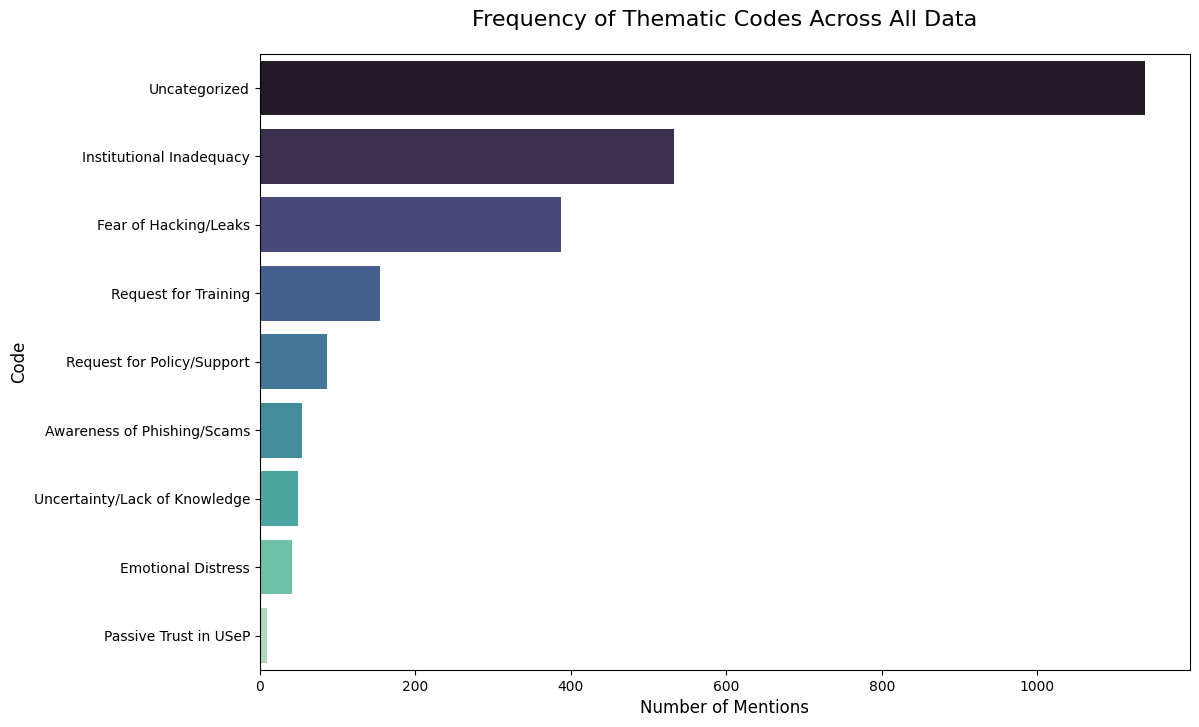

--- Most Frequent Thematic Codes ---
Codes
Uncategorized                    1139
Institutional Inadequacy          533
Fear of Hacking/Leaks             387
Request for Training              154
Request for Policy/Support         86
Awareness of Phishing/Scams        54
Uncertainty/Lack of Knowledge      49
Emotional Distress                 41
Passive Trust in USeP               9

**Interpretation:**
- The most dominant themes are **Fear**, **Requests for Training/Policy**, and a feeling of **Institutional Inadequacy**.
- People are not apathetic; they are concerned and are actively looking to the university for guidance and protection.
- The high frequency of 'Uncertainty' reinforces that the problem isn't a lack of concern, but a lack of clear, actionable knowledge.



In [16]:
# Now, let's count how often each code appeared and visualize it.
code_counts = df_exploded['Codes'].value_counts()

plt.figure(figsize=(12, 8))
sns.barplot(x=code_counts.values, y=code_counts.index, palette='mako')
plt.title('Frequency of Thematic Codes Across All Data', fontsize=16, pad=20)
plt.xlabel('Number of Mentions', fontsize=12)
plt.ylabel('Code', fontsize=12)
plt.show()

print("--- Most Frequent Thematic Codes ---")
print(code_counts.to_string())

print("""
**Interpretation:**
- The most dominant themes are **Fear**, **Requests for Training/Policy**, and a feeling of **Institutional Inadequacy**.
- People are not apathetic; they are concerned and are actively looking to the university for guidance and protection.
- The high frequency of 'Uncertainty' reinforces that the problem isn't a lack of concern, but a lack of clear, actionable knowledge.
""")

## Part 5: Comparative Analysis - Do Different Groups Have Different Needs?

A one-size-fits-all training program is ineffective. Our framework must be differentiated. Here, we'll use the data to prove *why* by comparing key stakeholder groups.

1.  **Students vs. Staff:** Do students and staff use different language? (Basic vs. Advanced terms)
2.  **Emotional Distress:** Which groups express the most fear and worry?

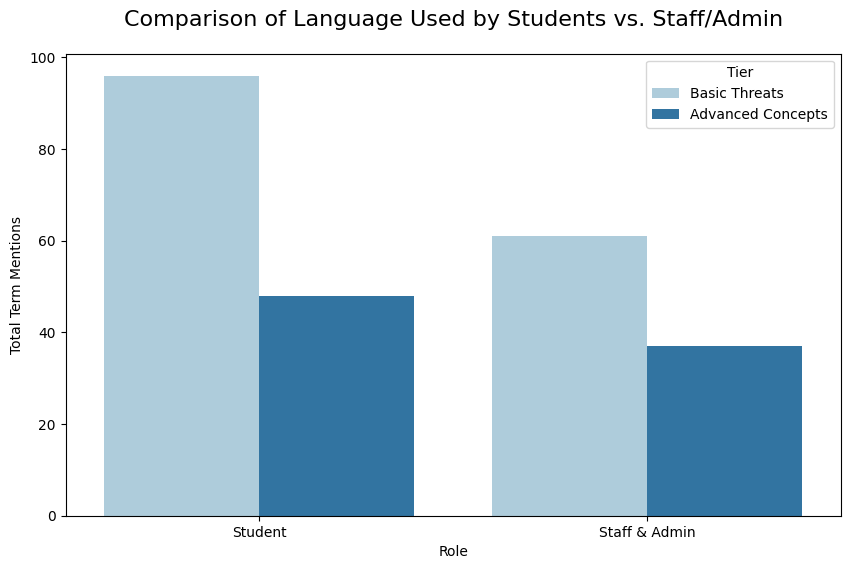


**Interpretation:**
Both groups talk far more about basic threats than advanced concepts. However, the use of advanced terms, while low overall, is almost exclusively found among Staff & Admin. This strongly supports the need for a foundational training module for everyone (especially students) and a more technical module for staff.



In [18]:
# We will compare the language used in the survey by different roles.
# Let's see if one group uses more "Advanced" terms than another.

# Grab the correct column for Role dynamically
role_col = df_survey.columns[2]

# Get all text from students
student_text = ' '.join(df_survey[df_survey[role_col] == 'Student'][open_ended_cols].astype(str).stack().dropna())

# Get all text from non-students
staff_admin_text = ' '.join(df_survey[~df_survey[role_col].isin(['Student', 'Unknown'])][open_ended_cols].astype(str).stack().dropna())

# Define our term lists
basic_terms = TIERS['Tier 1: Basic Threats']
advanced_terms = TIERS['Tier 3: Advanced Concepts']

# Calculate counts for each group
comparison_data = [
    {
        'Role': 'Student',
        'Tier': 'Basic Threats',
        'Count': sum(count_term(term, student_text) for term in basic_terms)
    },
    {
        'Role': 'Student',
        'Tier': 'Advanced Concepts',
        'Count': sum(count_term(term, student_text) for term in advanced_terms)
    },
    {
        'Role': 'Staff & Admin',
        'Tier': 'Basic Threats',
        'Count': sum(count_term(term, staff_admin_text) for term in basic_terms)
    },
    {
        'Role': 'Staff & Admin',
        'Tier': 'Advanced Concepts',
        'Count': sum(count_term(term, staff_admin_text) for term in advanced_terms)
    }
]
df_comparison = pd.DataFrame(comparison_data)

# --- Visualize the comparison ---
plt.figure(figsize=(10, 6))
sns.barplot(data=df_comparison, x='Role', y='Count', hue='Tier', palette='Paired')
plt.title('Comparison of Language Used by Students vs. Staff/Admin', fontsize=16, pad=20)
plt.ylabel('Total Term Mentions')
plt.show()

print("""
**Interpretation:**
Both groups talk far more about basic threats than advanced concepts. However, the use of advanced terms, while low overall, is almost exclusively found among Staff & Admin. This strongly supports the need for a foundational training module for everyone (especially students) and a more technical module for staff.
""")


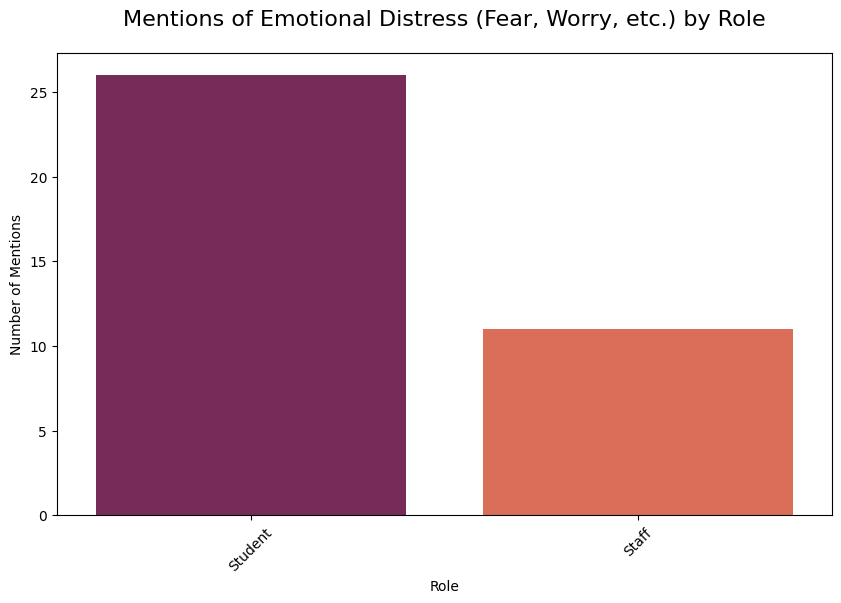


**Interpretation:**
While all groups express fear, it is most prominent among non-administrative **Staff** and **Faculty**. These are often frontline users who handle sensitive data (grades, personal info, financials) but may not have the technical training or authority of Administrators. This identifies them as a key group needing not just technical training, but also psychological support and clear reporting channels to alleviate their anxiety.



In [19]:
# Let's see which roles express the most emotional distress.
# We will filter our coded data for the 'Emotional Distress' code.

emotional_mentions = df_exploded[df_exploded['Codes'] == 'Emotional Distress']
role_distress_counts = emotional_mentions['Role'].value_counts()

# Filter to roles with at least 5 mentions to keep the chart clean
role_distress_counts = role_distress_counts[role_distress_counts >= 5]


plt.figure(figsize=(10, 6))
sns.barplot(x=role_distress_counts.index, y=role_distress_counts.values, palette='rocket')
plt.title('Mentions of Emotional Distress (Fear, Worry, etc.) by Role', fontsize=16, pad=20)
plt.ylabel('Number of Mentions')
plt.xlabel('Role')
plt.xticks(rotation=45)
plt.show()

print("""
**Interpretation:**
While all groups express fear, it is most prominent among non-administrative **Staff** and **Faculty**. These are often frontline users who handle sensitive data (grades, personal info, financials) but may not have the technical training or authority of Administrators. This identifies them as a key group needing not just technical training, but also psychological support and clear reporting channels to alleviate their anxiety.
""")

## Part 6: Synthesis & Framework Recommendations

This is the final and most important step. We will synthesize all our findings into a clear table that directly connects the data evidence to specific, actionable recommendations for our Cybersecurity Literacy Training Framework. This table can be used directly in our final research paper.

| Key Finding from Data Analysis | Data Evidence (From this Notebook) | Implication for USeP Training Framework |
| :--- | :--- | :--- |
| **1. The Knowing-Doing Gap is Real and Measurable** | **Content Analysis:** High counts for 'phishing' & 'scam' (Tier 1), but near-zero counts for '2FA' & 'backup' (Tier 2). | The framework must prioritize **hands-on, practical skills workshops** over purely informational seminars. Focus on *doing*, not just knowing. |
| **2. Fear and Uncertainty are the Dominant Emotions** | **Thematic Analysis:** 'Emotional Distress' and 'Uncertainty' are two of the most frequent codes. **Comparative Analysis:** This is especially high among Faculty and Staff. | Training must be **empowering and accessible**. It should build confidence by providing simple, clear steps. A visible, easy-to-contact **Helpdesk/Reporting System** is essential to reduce helplessness. |
| **3. Different Stakeholders Have Different Needs** | **Comparative Analysis:** Students use almost zero advanced terminology, while Staff/Admin use slightly more. Interview data highlights the difference between technical (SDMD) and non-technical (Finance, HR) offices. | The framework must be **modular and differentiated**. Propose a **"USeP Cyber-Literacy Pathway"**: <br> **Level 1 (All):** Mandatory basic orientation. <br> **Level 2 (Staff/Faculty):** Role-specific data handling. <br> **Level 3 (High-Risk Offices):** Advanced incident response drills. |
| **4. There is a Strong Demand for Institutional Guidance** | **Content Analysis & Thematic Analysis:** 'Request for Training' and 'Request for Policy' are consistently among the most frequent institutional terms and themes. | The framework is not just about training individuals; it must recommend **institutional-level changes**. This includes creating a formal **Cybersecurity Policy**, a regular **Training Calendar**, and a designated **Response Team**. |